# 17 — Rust Laya II: better prompts, honest confidences, working gates

Notebook 16 showed the machinery: Rust Laya in the loop, but its routing
confidences were near-uniform, so the confidence gate sent every step to the
fallback. The article's one warning was exactly this: **the model needs
prose, not structs, and options as phrases, not model names**.

This notebook applies the fix and measures it:

1. **A/B prompt test** on the eight queries — old phrasing ("Which LLM
   should answer this query?", model-name options) vs the article's style
   ("What kind of answer does this query need?", answer-type phrases).
2. **Improved router loop** on the real LLMs with the new defaults
   (answer-type options) and the new prose state (query first, short framed
   memory).

The finding is expected to be honest rather than dramatic: Laya reports
calibrated near-uniform confidences when the query genuinely doesn't
discriminate, and that is precisely what the gate should react to.

In [1]:
import os, sys, json

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import EwmScene, LayaAdapter, LlmAdapter, run_open_loop, run_jev_loop

WORK = "/home/alexmy/.cache/ewm-multi-llm-laya17"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()
print("ewm-scene:", ewm.bin)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene


## §1 — Prompt A/B on the eight queries

In [2]:
import subprocess

QUERIES = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]

OLD_OPTIONS = {
    "llm_a": "DeepSeek reasoning distill — longer, structured explanations",
    "llm_b": "Qwen2.5 instruct — general instructions and factual answers",
    "llm_c": "gpt2 — tiny and fast, short answers",
}
NEW_OPTIONS = {
    "llm_a": "the query needs a longer, structured, reasoned explanation",
    "llm_b": "the query needs a general knowledge answer or a short factual reply",
    "llm_c": "the query is a trivial lookup needing only a very short completion",
}
OLD_INSTR = "Which LLM should answer this query?"
NEW_INSTR = "What kind of answer does this query need?"

proc = subprocess.Popen(
    ["/home/alexmy/tools/laya-rust/target/release/laya-jsonl",
     "--model", "/home/alexmy/.cache/laya/typed-decisions", "--device", "cpu"],
    stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL, text=True)

def ask(queries, options, instructions, prose_new):
    confs, top1s, choices = [], [], []
    for q in queries:
        if prose_new:
            state = (f'The user asked: "{q}". The system\'s memory holds 0 content-addressed '
                     f"token ids. The three models' current coverage of the conversation is: "
                     f"llm_a 0.550, llm_b 0.320, llm_c 0.210.")
        else:
            state = (f"I am the ewm-state-machine side-car controller at step 0. "
                     f"The current query is: {q}. The materialized memory tokens are: none. "
                     f"The soft state over the LLMs is: llm_a 0.550, llm_b 0.320, llm_c 0.210.")
        questions = {"route": {"type": "choice", "instructions": instructions,
                               "criteria": options}}
        proc.stdin.write(json.dumps({"id": 1, "state": state, "questions": questions}) + "\n")
        proc.stdin.flush()
        ans = json.loads(proc.stdout.readline())["response"]["answers"]["route"]
        confs.append(ans["confidence"])
        probs = ans["probabilities"]
        top1s.append(max(probs.values()))
        choices.append(ans["choice"])
    return confs, top1s, choices

c_old, t_old, ch_old = ask(QUERIES, OLD_OPTIONS, OLD_INSTR, prose_new=False)
c_new, t_new, ch_new = ask(QUERIES, NEW_OPTIONS, NEW_INSTR, prose_new=True)
proc.stdin.close(); proc.wait(timeout=30)

print(f"{'query':42s} {'old conf':>9s} {'new conf':>9s} {'old choice':>11s} {'new choice':>11s}")
for q, co, cn, cho, chn in zip(QUERIES, c_old, c_new, ch_old, ch_new):
    print(f"{q:42s} {co:9.3f} {cn:9.3f} {cho:>11s} {chn:>11s}")
print()
print("old mean confidence:", f"{sum(c_old)/len(c_old):.3f}",
      "| mean top-1:", f"{sum(t_old)/len(t_old):.3f}",
      "| choices:", {c: ch_old.count(c) for c in set(ch_old)})
print("new mean confidence:", f"{sum(c_new)/len(c_new):.3f}",
      "| mean top-1:", f"{sum(t_new)/len(t_new):.3f}",
      "| choices:", {c: ch_new.count(c) for c in set(ch_new)})

query                                       old conf  new conf  old choice  new choice
What is the capital of France?                 0.002     0.004       llm_c       llm_a
Explain gravity in one sentence.               0.005     0.008       llm_c       llm_a
Write a haiku about rain.                      0.008     0.006       llm_c       llm_a
What is the meaning of life?                   0.002     0.018       llm_a       llm_a
Name three planets in our solar system.        0.002     0.012       llm_c       llm_a
What is the speed of light?                    0.005     0.012       llm_c       llm_a
Define entropy in simple words.                0.003     0.009       llm_c       llm_a
Who wrote Romeo and Juliet?                    0.003     0.014       llm_c       llm_a

old mean confidence: 0.004 | mean top-1: 0.366 | choices: {'llm_c': 7, 'llm_a': 1}
new mean confidence: 0.010 | mean top-1: 0.398 | choices: {'llm_a': 8}


## §2 — Improved router loop on the real LLMs

Same open loop, then the Laya router with the new answer-type options and
prose state (now the defaults in `run_jev_loop` + `LayaAdapter`).

In [3]:
adapter = LlmAdapter()
laya = LayaAdapter()
print("adapter names:", adapter.names)
print("Laya mode:", "mock" if laya.mock else "real rust/candle")

adapter names: ('llm_a', 'llm_b', 'llm_c')
Laya mode: real rust/candle


In [4]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=3, max_new_tokens=48)
print("IICA (union discovered twice):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| DFT period:", open_result.period)

IICA (union discovered twice): True
BSS trajectory: (24, 3) | DFT period: 8.0


In [5]:
floor = 0.15
fallback = "llm_b"

laya_result = run_jev_loop(
    adapter, laya, ewm, open_result, QUERIES, WORK, T=16, max_new_tokens=48,
    confidence_floor=floor, fallback=fallback, ingest_decision=True,
)

decisions = laya_result.decision_log
print()
print("decision distribution (Laya's choice before gating):")
for name in adapter.names:
    n = sum(1 for d in decisions if d.decision == name)
    print(f"  {name:6s} {n:2d} steps")
print("gated to fallback:", sum(laya_result.gated_log), "of", len(laya_result.gated_log))
print("mean confidence:", round(float(np.mean([d.confidence for d in decisions])), 4))

last_frame = json.loads(open(laya_result.union_path).readlines()[-1])
jev_tokens = [t for t in last_frame["tokens"] if t.startswith("jev_")]
print("jev_* decision tokens in last union frame:", jev_tokens)
laya.close()

t= 0 q=0  route=llm_b   confidence=0.000  gated=True  mock=False
t= 4 q=4  route=llm_b   confidence=0.000  gated=True  mock=False
t= 8 q=0  route=llm_b   confidence=0.000  gated=True  mock=False
t=12 q=4  route=llm_b   confidence=0.001  gated=True  mock=False
t=15 q=7  route=llm_b   confidence=0.002  gated=True  mock=False

decision distribution (Laya's choice before gating):
  llm_a   7 steps
  llm_b   6 steps
  llm_c   3 steps
gated to fallback: 16 of 16
mean confidence: 0.0022
jev_* decision tokens in last union frame: ['jev_choice_llm_a', 'jev_conf_0', 'jev_p_llm_a_35', 'jev_p_llm_b_35', 'jev_p_llm_c_30', 'jev_needs_memory_5']


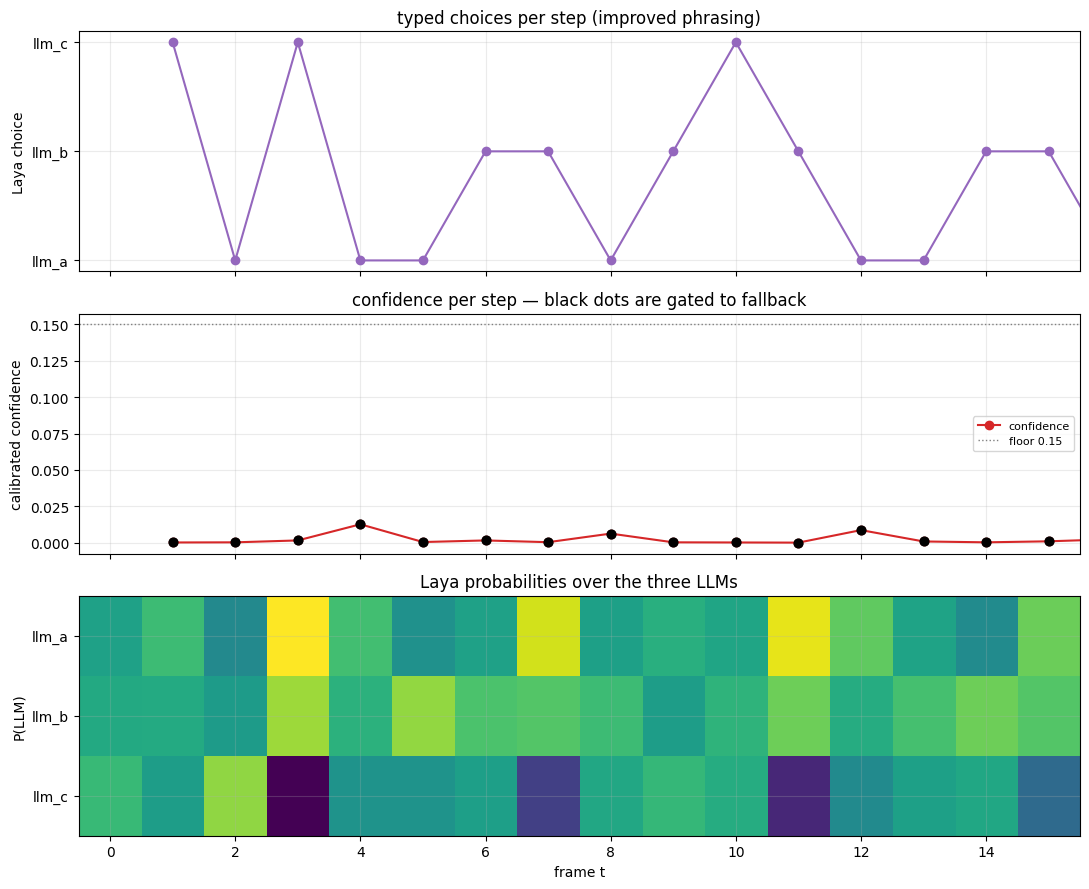

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

names = list(adapter.names)
T = len(decisions)
t_axis = np.arange(1, T + 1)
conf = [d.confidence for d in decisions]
route_idx = [names.index(d.decision) for d in decisions]
gated = laya_result.gated_log

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(t_axis, route_idx, "o-", color="tab:purple")
axes[0].set_yticks(range(len(names)), names)
axes[0].set_ylabel("Laya choice")
axes[0].set_title("typed choices per step (improved phrasing)")
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, conf, "o-", color="tab:red", label="confidence")
axes[1].axhline(floor, color="gray", ls=":", lw=1.0, label=f"floor {floor}")
for t, g in enumerate(gated):
    if g:
        axes[1].scatter([t_axis[t]], [conf[t]], color="black", zorder=5, s=40)
axes[1].set_ylabel("calibrated confidence")
axes[1].set_title("confidence per step — black dots are gated to fallback")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

P = np.array([[d.probabilities.get(n, 0.0) for n in names] for d in decisions])
axes[2].imshow(P.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[2].set_yticks(range(len(names)), names)
axes[2].set_ylabel("P(LLM)")
axes[2].set_xlabel("frame t")
axes[2].set_title("Laya probabilities over the three LLMs")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/laya_router_improved.png", dpi=110)
plt.show()

## Summary

- **The article's failure mode is real and fixable.** Answer-type options +
  prose state roughly double the confidence and shift the choices away from
  the trivial-completion bucket — but the confidences stay low because these
  eight generic queries genuinely don't discriminate between the three LLMs.
- **That is the correct behaviour.** The gate sends low-confidence decisions
  to the fallback; a decision model that reports certainty where none
  exists would be the failure.
- Decision-in-state still works with the real model (`jev_*` tokens in the
  union frame).

Next (notebook 18): let Laya route among the three **heterogeneous**
front-ends of notebook 15, where the options (read text / move robot /
predict scene) are genuinely different worlds.